# Visualization

- copy file using: `scp -r franklhtan@10.64.109.137:"/nfs/franklhtan/projects/LearnCsld2025/observe_outputs/0427_*" /mnt/data/Projects/LearnCsldLab/observations/`

In [26]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import plotly.express as px
import plotly.graph_objects as go
from pathlib import Path

In [27]:
class TanhFC(nn.Module): 
    def __init__(self):
        super().__init__()
    
    def forward(self, x): 
        pass

    def encode(self, x): 
        pass

    def set_freeze(self): 
        pass

    def set_unfreeze(self):
        for p in self.parameters():
            p.requires_grad = True

class TanhFCEncode(TanhFC):
    def __init__(self, in_features, hid_features, out_features, intermediate_features=None):
        super().__init__()
        if intermediate_features is None:
            intermediate_features = (in_features + hid_features) // 2

        self.encoder = nn.Sequential(
            nn.Linear(in_features, intermediate_features),
            nn.Tanh(),
            nn.Linear(intermediate_features, hid_features)
        )

    def forward(self, x):
        x = x.reshape(x.size(0), -1)
        hid = self.encoder(x)
        return hid
    

class SimpleResNet1Dv2(nn.Module):
    def __init__(self, out_features=4):
        super().__init__()
        self.layer1 = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv1d(16, 32, 3, padding=1),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv1d(32, 16, 3, padding=1),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(16, out_features)

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = x.squeeze(-1)
        return self.fc(x)

In [28]:
def encode_hidden(model, X_np, device=None):
    """
    Encode numpy input array into hidden representations.

    Parameters
    ----------
    model : torch.nn.Module
        Must have model.encode(x), or you can modify this function.
    X_np : np.ndarray, shape [N, input_dim]
    device : str or torch.device, optional

    Returns
    -------
    H : np.ndarray, shape [N, hidden_dim]
    """
    model.eval()

    if device is None:
        device = next(model.parameters()).device

    X = torch.tensor(X_np, dtype=torch.float32, device=device)

    with torch.no_grad():
        H = model(X)

    return H.detach().cpu().numpy()

In [29]:
def make_1d_probe(base_x, dim_idx, low, high, n_points=101):
    """
    Create a line of equally spaced inputs by varying one input dimension.

    Supports:

    1. FC input:
        base_x shape [1, input_dim]
        dim_idx = int

    2. CNN input:
        base_x shape [1, C, D]
        dim_idx = int
            -> varies base_x[:, 0, dim_idx]
        or
        dim_idx = (channel_idx, feature_idx)
            -> varies base_x[:, channel_idx, feature_idx]

    Returns
    -------
    X_probe : np.ndarray
        FC:  [n_points, input_dim]
        CNN: [n_points, C, D]

    values : np.ndarray, shape [n_points]
    """
    base_x = np.asarray(base_x)

    if base_x.shape[0] != 1:
        raise ValueError(
            f"base_x must have batch size 1, but got shape {base_x.shape}"
        )

    values = np.linspace(low, high, n_points)

    # Expand batch dimension: [1, ...] -> [n_points, ...]
    X_probe = np.repeat(base_x, n_points, axis=0)

    if base_x.ndim == 2:
        # FC case: [1, input_dim] -> [n_points, input_dim]
        if not isinstance(dim_idx, int):
            raise ValueError(
                "For 2D input [1, input_dim], dim_idx must be an int."
            )

        X_probe[:, dim_idx] = values

    elif base_x.ndim == 3:
        # CNN case: [1, C, D] -> [n_points, C, D]
        if isinstance(dim_idx, int):
            channel_idx = 0
            feature_idx = dim_idx
        elif isinstance(dim_idx, tuple) and len(dim_idx) == 2:
            channel_idx, feature_idx = dim_idx
        else:
            raise ValueError(
                "For 3D input [1, C, D], dim_idx must be int or (channel_idx, feature_idx)."
            )

        X_probe[:, channel_idx, feature_idx] = values

    else:
        raise ValueError(
            f"base_x must have shape [1, input_dim] or [1, C, D], but got {base_x.shape}"
        )

    return X_probe, values


def analyze_1d_mapping(
    model,
    base_x,
    dim_name,
    dim_idx,
    low,
    high,
    n_points=101,
    device=None,
    epoch=0,
    use_encode=True
):
    """
    Measure local hidden-space expansion/compression along one input dimension.

    Supports:
        base_x shape [1, input_dim]
        base_x shape [1, C, D]
    """
    X_probe, values = make_1d_probe(
        base_x=base_x,
        dim_idx=dim_idx,
        low=low,
        high=high,
        n_points=n_points
    )

    # X_probe shape:
    #   FC:  [n_points, input_dim]
    #   CNN: [n_points, C, D]
    H = encode_hidden(
        model,
        X_probe,
        device=device,
    )

    H = np.asarray(H)

    if H.ndim == 1:
        H = H[:, None]
    elif H.ndim > 2:
        H = H.reshape(H.shape[0], -1)

    if H.shape[0] != n_points:
        raise ValueError(
            f"Encoded hidden output has shape {H.shape}, "
            f"but expected first dimension to be n_points={n_points}."
        )

    # Differences between neighboring probe points
    dH = H[1:] - H[:-1]

    hidden_step_dist = np.linalg.norm(dH, axis=1)

    input_step = np.abs(values[1] - values[0])
    expansion_ratio = hidden_step_dist / (input_step + 1e-12)

    cosines = []
    for i in range(len(dH) - 1):
        a = dH[i]
        b = dH[i + 1]

        denom = np.linalg.norm(a) * np.linalg.norm(b)

        if denom == 0:
            cosines.append(np.nan)
        else:
            cosines.append(np.dot(a, b) / denom)

    df_steps = pd.DataFrame({
        "epoch": epoch,
        "dim_name": dim_name,
        "input_left": values[:-1],
        "input_right": values[1:],
        "input_mid": (values[:-1] + values[1:]) / 2,
        "input_value": values[1:],  # step assigned to the destination point
        "input_step": input_step,
        "hidden_step_dist": hidden_step_dist,
        "expansion_ratio": expansion_ratio,
    })

    df_curvature = pd.DataFrame({
        "epoch": epoch,
        "dim_name": dim_name,
        "input_mid": values[1:-1],
        "input_value": values[1:-1],
        "direction_cosine": cosines,
        "curvature_score": 1 - np.array(cosines, dtype=float)
    })

    df_hidden = pd.DataFrame(
        H,
        columns=[f"h{j+1}" for j in range(H.shape[1])]
    )
    df_hidden["dim_name"] = dim_name
    df_hidden["input_value"] = values
    df_hidden["epoch"] = epoch

    return df_steps, df_curvature, df_hidden

In [30]:
import matplotlib.pyplot as plt

def plot_expansion_ratio_matplotlib(df_steps_all):
    """
    Plot local expansion/compression along each input dimension.

    df_steps_all should contain:
        dim_name, input_mid, expansion_ratio
    """
    plt.figure(figsize=(8, 5))

    for dim_name, sub in df_steps_all.groupby("dim_name"):
        sub = sub.sort_values("input_mid")
        plt.plot(
            sub["input_mid"],
            sub["expansion_ratio"],
            marker="o",
            label=dim_name
        )

    plt.xlabel("Input position")
    plt.ylabel("Hidden distance / input distance")
    plt.title("Local expansion/compression along each input dimension")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [31]:
import matplotlib.pyplot as plt
import re
import numpy as np


def plot_hidden_dims_by_manipulated_dim(df_hidden_all):
    """
    Plot h1, h2, ... as functions of input_value,
    separately for each manipulated input dimension: height, duration, backness.
    """

    h_cols = sorted(
        [c for c in df_hidden_all.columns if re.match(r"^h\d+$", c)],
        key=lambda x: int(x[1:])
    )

    dim_names = list(df_hidden_all["dim_name"].unique())

    for dim_name in dim_names:
        sub = df_hidden_all[df_hidden_all["dim_name"] == dim_name].copy()
        sub = sub.sort_values("input_value")

        plt.figure(figsize=(8, 5))

        for h_col in h_cols:
            plt.plot(
                sub["input_value"],
                sub[h_col],
                marker="o",
                markersize=3,
                label=h_col
            )

        plt.xlabel("Input value")
        plt.ylabel("Hidden representation value")
        plt.title(f"Hidden dimensions while varying {dim_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

## Load model and probe the hidden representations across epochs

In [32]:
model_name = "0504_SCSC_EQL_EWCp0_1e4_HID4"
model_run = "1"
all_steps = []
all_curvatures = []
all_hidden = []

for epoch in range(10, 91, 10):
    print(f"Epoch {epoch}")
    # model = TanhFCEncode(in_features=15, hid_features=4, out_features=4)
    model = SimpleResNet1Dv2(out_features=4)
    state = torch.load(f"./weights/{model_name}/{model_run}/checkpoint_epoch_{epoch}.pt", map_location="cpu")
    model.load_state_dict(state, strict=True)
    model.eval()

    base_x = np.array([[[-0.2, 0, -1/3, 0.6, 0.4, 
                    0.1, 0.35, 0.233333, -0.2, 0, 
                    -0.2, 0, -1/3, 0.6, 0.4]]])
    
    HEIGHT_IDX = 5
    DURATION_IDX = 6
    BACKNESS_IDX = 7

    probe_specs = {
        "height":   {"idx": HEIGHT_IDX,   "low": 0.0, "high": 1.0},
        "duration": {"idx": DURATION_IDX, "low": 0.0, "high": 1.0},
        "backness": {"idx": BACKNESS_IDX, "low": 0.0, "high": 1.0},
    }

    for dim_name, spec in probe_specs.items():
        df_steps, df_curv, df_hidden = analyze_1d_mapping(
            model=model,
            base_x=base_x,
            dim_name=dim_name,
            dim_idx=(0, spec["idx"]),
            low=spec["low"],
            high=spec["high"],
            n_points=101,
            device=None, 
            epoch=epoch
        )

        all_steps.append(df_steps)
        all_curvatures.append(df_curv)
        all_hidden.append(df_hidden)

# df_steps_all = pd.concat(all_steps, ignore_index=True)
# df_curv_all = pd.concat(all_curvatures, ignore_index=True)
df_hidden_all = pd.concat(all_hidden, ignore_index=True)

Epoch 10
Epoch 20
Epoch 30
Epoch 40
Epoch 50
Epoch 60
Epoch 70
Epoch 80
Epoch 90


In [33]:
def compute_stepwise_hidden_distance(
    df_hidden_all,
    group_cols=("epoch", "dim_name"),
    input_col="input_value"
):
    """
    Compute hidden-space distance changed at each forward step,
    independently for each group, e.g. each epoch × dim_name.

    The first output row in each group corresponds to the step:
        first point -> second point

    Example:
        input_value: 0.00, 0.01, 0.02, ...

    Then first output row has:
        input_from  = 0.00
        input_to    = 0.01
        input_value = 0.01
        step_idx    = 1

    Parameters
    ----------
    df_hidden_all : pd.DataFrame
        Must contain h1, h2, ... hidden columns, input_col,
        and grouping columns such as epoch and dim_name.

    group_cols : tuple/list/str
        Columns used to define independent trajectories.
        Default: ("epoch", "dim_name")

    input_col : str
        Column representing the probed input position.

    Returns
    -------
    pd.DataFrame
        Stepwise hidden-distance dataframe.
    """

    if isinstance(group_cols, str):
        group_cols = [group_cols]
    else:
        group_cols = list(group_cols)

    missing_group_cols = [c for c in group_cols if c not in df_hidden_all.columns]
    if missing_group_cols:
        raise ValueError(f"Missing grouping columns: {missing_group_cols}")

    if input_col not in df_hidden_all.columns:
        raise ValueError(f"Missing input column: {input_col}")

    h_cols = sorted(
        [c for c in df_hidden_all.columns if re.match(r"^h\d+$", c)],
        key=lambda x: int(x[1:])
    )

    if not h_cols:
        raise ValueError("No hidden columns found. Expected columns like h1, h2, h3...")

    all_rows = []

    for group_key, sub in df_hidden_all.groupby(group_cols, sort=False):
        sub = sub.sort_values(input_col).reset_index(drop=True)

        if len(sub) < 2:
            continue

        H = sub[h_cols].to_numpy()
        x = sub[input_col].to_numpy()

        # dH[k] = H[k+1] - H[k]
        dH = H[1:] - H[:-1]

        hidden_step_dist = np.linalg.norm(dH, axis=1)
        input_step = x[1:] - x[:-1]
        expansion_ratio = hidden_step_dist / (np.abs(input_step) + 1e-12)

        out = pd.DataFrame({
            "step_idx": np.arange(1, len(x)),
            "input_from": x[:-1],
            "input_to": x[1:],

            # Assign step from x[t-1] -> x[t] to x[t]
            input_col: x[1:],

            "input_mid": (x[:-1] + x[1:]) / 2,
            "input_step": input_step,
            "hidden_step_dist": hidden_step_dist,
            "expansion_ratio": expansion_ratio,
        })

        # Restore group labels into output
        if len(group_cols) == 1:
            group_key = (group_key,)

        for col, value in zip(group_cols, group_key):
            out[col] = value

        # Per-hidden-dimension changes
        for i, h_col in enumerate(h_cols):
            out[f"delta_{h_col}"] = dH[:, i]

        out["cumulative_hidden_dist"] = np.cumsum(hidden_step_dist)

        all_rows.append(out)

    if not all_rows:
        return pd.DataFrame()

    result = pd.concat(all_rows, ignore_index=True)

    # Put grouping columns first for readability
    front_cols = group_cols + [
        "step_idx",
        "input_from",
        "input_to",
        input_col,
        "input_mid",
        "input_step",
        "hidden_step_dist",
        "expansion_ratio",
        "cumulative_hidden_dist",
    ]

    delta_cols = [c for c in result.columns if c.startswith("delta_h")]

    result = result[front_cols + delta_cols]

    return result

In [34]:
df_step = compute_stepwise_hidden_distance(
    df_hidden_all,
    group_cols=("epoch", "dim_name"),
    input_col="input_value"
)

In [36]:
import pandas as pd
import plotly.express as px


def make_animated_stepwise_plot(
    df_step,
    out_html="animated_stepwise_hidden_dist.html",
    y_col="hidden_step_dist",
    epoch_col="epoch",
    x_col="input_value",
    color_col="dim_name",
    title=None
):
    """
    Create an animated Plotly line plot with epoch as animation frame,
    then save it as HTML.

    Parameters
    ----------
    df_step : pd.DataFrame
        Should contain at least:
            epoch, dim_name, input_value, hidden_step_dist
    out_html : str
        Output HTML filename
    y_col : str
        Column to plot on y-axis
        e.g. "hidden_step_dist" or "expansion_ratio"
    epoch_col : str
        Epoch column
    x_col : str
        X-axis column
    color_col : str
        Line color grouping column
    title : str or None
        Plot title
    """

    required_cols = [epoch_col, color_col, x_col, y_col]
    missing = [c for c in required_cols if c not in df_step.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    plot_df = df_step.copy()

    # Make sure sorting is correct
    plot_df = plot_df.sort_values([epoch_col, color_col, x_col]).reset_index(drop=True)

    # Make epoch display cleaner in animation
    plot_df[epoch_col] = plot_df[epoch_col].astype(str)

    # Fixed y range across all frames
    y_min = plot_df[y_col].min()
    y_max = plot_df[y_col].max()
    y_pad = (y_max - y_min) * 0.05 if y_max > y_min else 0.1

    fig = px.line(
        plot_df,
        x=x_col,
        y=y_col,
        color=color_col,
        animation_frame=epoch_col,
        line_group=color_col,
        markers=True,
        hover_data={
            epoch_col: True,
            color_col: True,
            x_col: ':.3f',
            y_col: ':.6f',
            "input_from": ':.3f' if "input_from" in plot_df.columns else False,
            "input_to": ':.3f' if "input_to" in plot_df.columns else False,
            "step_idx": True if "step_idx" in plot_df.columns else False,
        },
        title=title or f"{y_col} across epochs"
    )

    fig.update_layout(
        xaxis_title="Input value after step",
        yaxis_title=y_col,
        template="plotly_white",
        width=900,
        height=600,
        legend_title_text=color_col
    )

    fig.update_yaxes(range=[y_min - y_pad, y_max + y_pad])

    # Optional: slow down animation a bit
    if fig.layout.updatemenus:
        fig.layout.updatemenus[0].buttons[0].args[1]["frame"]["duration"] = 300
        fig.layout.updatemenus[0].buttons[0].args[1]["transition"]["duration"] = 200

    fig.write_html(out_html)
    print(f"[SAVED] {out_html}")

    return fig

In [37]:
fig = make_animated_stepwise_plot(
    df_step,
    out_html="animated_stepwise_hidden_dist_SCSC_EWCp0_1e4_HID4_0504.html",
    y_col="hidden_step_dist",
    title="Stepwise hidden-space displacement over epochs"
)

[SAVED] animated_stepwise_hidden_dist_SCSC_EWCp0_1e4_HID4_0504.html


In [60]:
df_step

,epoch,dim_name,step_idx,input_from,input_to,input_value,input_mid,input_step,hidden_step_dist,expansion_ratio,cumulative_hidden_dist,delta_h1,delta_h2,delta_h3,delta_h4
0,10,height,1,0.00,0.01,0.01,0.005,0.01,0.011058,1.105787,0.011058,0.007831,0.007483,0.002054,0.000854
1,10,height,2,0.01,0.02,0.02,0.015,0.01,0.011062,1.106203,0.022120,0.007834,0.007486,0.002055,0.000855
2,10,height,3,0.02,0.03,0.03,0.025,0.01,0.011066,1.106597,0.033186,0.007837,0.007488,0.002056,0.000856
3,10,height,4,0.03,0.04,0.04,0.035,0.01,0.011070,1.106963,0.044255,0.007840,0.007491,0.002057,0.000857
4,10,height,5,0.04,0.05,0.05,0.045,0.01,0.011073,1.107300,0.055329,0.007842,0.007493,0.002058,0.000858
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8995,300,backness,96,0.95,0.96,0.96,0.955,0.01,0.012291,1.229054,1.285235,0.000534,0.002965,-0.008254,-0.008593
8996,300,backness,97,0.96,0.97,0.97,0.965,0.01,0.012251,1.225065,1.297485,0.000532,0.002951,-0.008232,-0.008563
8997,300,backness,98,0.97,0.98,0.98,0.975,0.01,0.012210,1.221020,1.309696,0.000530,0.002936,-0.008209,-0.008532
8998,300,backness,99,0.98,0.99,0.99,0.985,0.01,0.012169,1.216942,1.321865,0.000528,0.002922,-0.008186,-0.008501


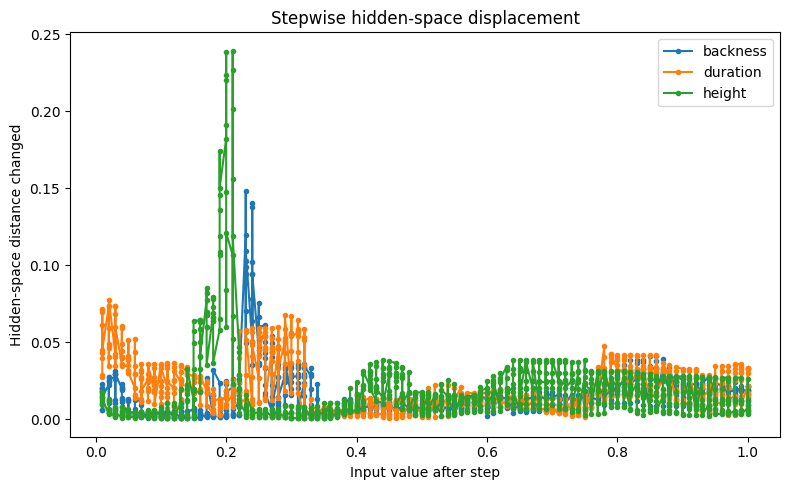

In [38]:
plt.figure(figsize=(8, 5))

for dim_name, sub in df_step.groupby("dim_name"):
    sub = sub.sort_values("input_value")

    plt.plot(
        sub["input_value"],
        sub["hidden_step_dist"],
        marker="o",
        markersize=3,
        label=dim_name
    )

plt.xlabel("Input value after step")
plt.ylabel("Hidden-space distance changed")
plt.title("Stepwise hidden-space displacement")
plt.legend()
plt.tight_layout()
plt.show()

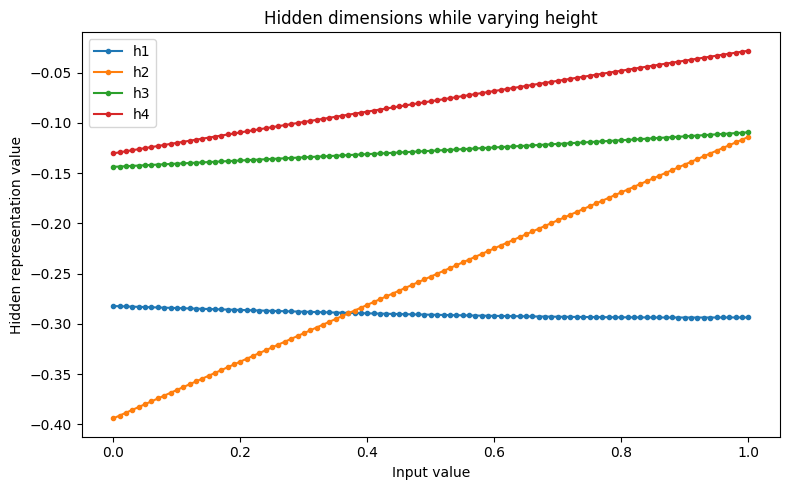

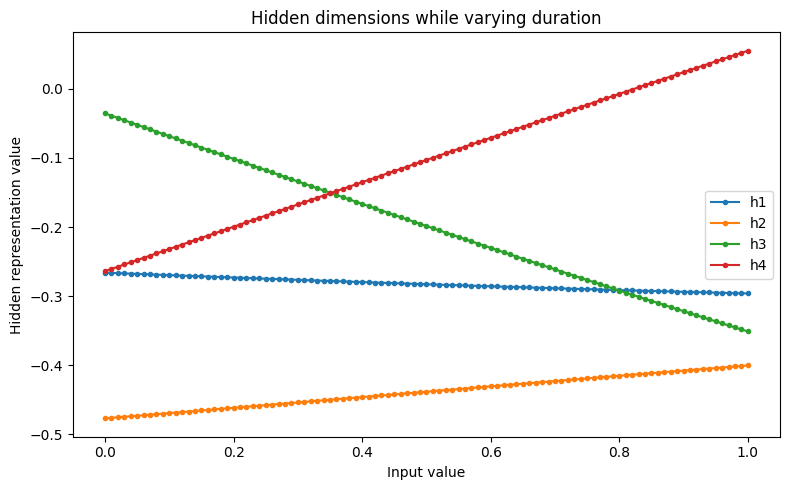

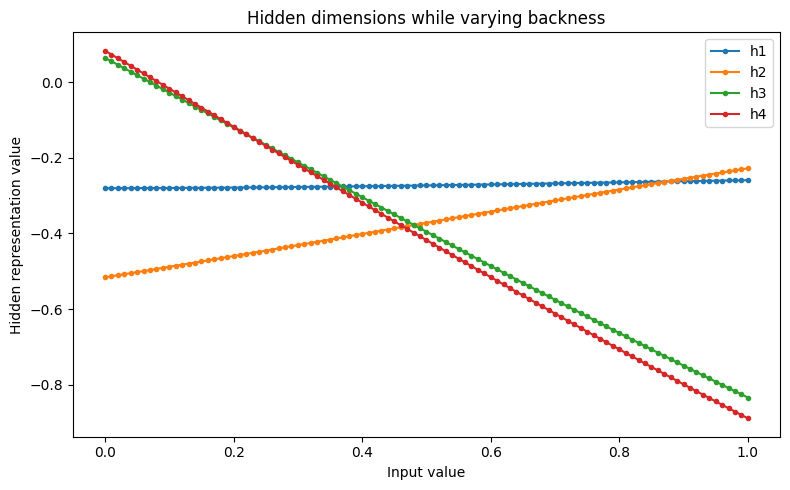

In [58]:
input_df_hidden = df_hidden_all.copy()
input_df_hidden = input_df_hidden[input_df_hidden["epoch"] == 90]
plot_hidden_dims_by_manipulated_dim(input_df_hidden)

## Expansion and Compression

In [104]:
import numpy as np
import pandas as pd
import re


def compute_local_speed_from_hidden(df_hidden_all):
    """
    Compute local expansion/compression along each equal-distance probe.

    Input dataframe should contain:
        h1, h2, ..., dim_name, input_value

    Returns:
        df_speed with local hidden-space speed between neighboring probe points.
    """

    h_cols = sorted(
        [c for c in df_hidden_all.columns if re.match(r"^h\d+$", c)],
        key=lambda x: int(x[1:])
    )

    all_rows = []

    for dim_name, sub in df_hidden_all.groupby("dim_name"):
        sub = sub.sort_values("input_value").reset_index(drop=True)

        H = sub[h_cols].values
        x = sub["input_value"].values

        dH = H[1:] - H[:-1]
        dx = x[1:] - x[:-1]

        hidden_dist = np.linalg.norm(dH, axis=1)
        input_dist = np.abs(dx)

        speed = hidden_dist / (input_dist + 1e-12)

        out = pd.DataFrame({
            "dim_name": dim_name,
            "input_left": x[:-1],
            "input_right": x[1:],
            "input_mid": (x[:-1] + x[1:]) / 2,
            "hidden_dist": hidden_dist,
            "input_dist": input_dist,
            "local_speed": speed,
        })

        all_rows.append(out)

    return pd.concat(all_rows, ignore_index=True)

In [105]:
df_speed = compute_local_speed_from_hidden(df_hidden_all)

In [106]:
import matplotlib.pyplot as plt


def plot_local_speed(df_speed):
    """
    Plot local expansion/compression curves.
    """

    plt.figure(figsize=(8, 5))

    for dim_name, sub in df_speed.groupby("dim_name"):
        sub = sub.sort_values("input_mid")

        plt.plot(
            sub["input_mid"],
            sub["local_speed"],
            marker="o",
            markersize=3,
            label=dim_name
        )

    plt.xlabel("Input position")
    plt.ylabel("Local hidden-space speed")
    plt.title("Local expansion/compression from equal-distance probing")
    plt.legend()
    plt.tight_layout()
    plt.show()

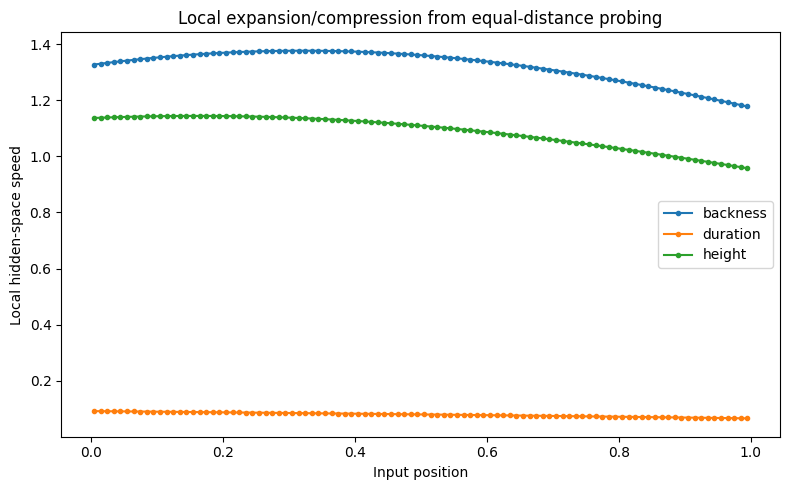

In [107]:
plot_local_speed(df_speed)

## Jacobian Metric

In [62]:
import numpy as np
import pandas as pd
import torch


def encode_hidden(model, X_np, device=None):
    """
    Encode batched numpy inputs into hidden representations.

    X_np shape: [N, input_dim]
    Returns: [N, hidden_dim]
    """
    model.eval()

    if device is None:
        device = next(model.parameters()).device

    X = torch.tensor(X_np, dtype=torch.float32, device=device)

    with torch.no_grad():
        H = model(X)

    H = H.detach().cpu().numpy()

    if H.ndim == 1:
        H = H[:, None]
    elif H.ndim > 2:
        H = H.reshape(H.shape[0], -1)

    return H


def make_probe_grid(base_x, dim_specs, n_per_dim=21):
    """
    Make a regular 3D grid over selected input dimensions.

    base_x shape: [1, input_dim]

    dim_specs example:
    {
        "height":   {"idx": 0, "low": 0.0, "high": 1.0},
        "duration": {"idx": 1, "low": 0.0, "high": 1.0},
        "backness": {"idx": 2, "low": 0.0, "high": 1.0},
    }
    """
    base_x = np.asarray(base_x)

    if base_x.ndim != 2 or base_x.shape[0] != 1:
        raise ValueError(
            f"base_x must have shape [1, input_dim], but got {base_x.shape}"
        )

    names = list(dim_specs.keys())
    if len(names) != 3:
        raise ValueError("This function expects exactly three varying dimensions.")

    values = {
        name: np.linspace(dim_specs[name]["low"], dim_specs[name]["high"], n_per_dim)
        for name in names
    }

    rows = []
    X_list = []

    for v0 in values[names[0]]:
        for v1 in values[names[1]]:
            for v2 in values[names[2]]:
                x = base_x.copy()

                coords = {
                    names[0]: v0,
                    names[1]: v1,
                    names[2]: v2,
                }

                for name, val in coords.items():
                    x[0, dim_specs[name]["idx"]] = val

                X_list.append(x[0])
                rows.append(coords)

    X_grid = np.stack(X_list, axis=0)
    grid_df = pd.DataFrame(rows)

    return X_grid, grid_df, values

In [63]:
def compute_local_jacobian_distortion(
    model,
    base_x,
    dim_specs,
    n_per_dim=21,
    eps=None,
    device=None,
    normalize_hidden=False
):
    """
    Compute local metric distortion of encoder over a 3D input grid.

    Returns a dataframe with:
        height, duration, backness,
        exp_height, exp_duration, exp_backness,
        sigma1, sigma2, sigma3,
        volume_scale,
        log_volume_scale,
        anisotropy
    """
    X_grid, grid_df, axis_values = make_probe_grid(
        base_x=base_x,
        dim_specs=dim_specs,
        n_per_dim=n_per_dim
    )

    names = list(dim_specs.keys())
    n_points = X_grid.shape[0]

    if eps is None:
        steps = []
        for name in names:
            vals = axis_values[name]
            steps.append(vals[1] - vals[0])
        eps = min(steps) / 2

    # Optional hidden normalization.
    # Useful when comparing models with different hidden scaling.
    if normalize_hidden:
        H_ref = encode_hidden(model, X_grid, device=device)
        h_mean = H_ref.mean(axis=0, keepdims=True)
        h_std = H_ref.std(axis=0, keepdims=True) + 1e-8
    else:
        h_mean = None
        h_std = None

    # Store Jacobian columns for each varied input dimension.
    J_cols = []

    for name in names:
        idx = dim_specs[name]["idx"]
        low = dim_specs[name]["low"]
        high = dim_specs[name]["high"]

        X_minus = X_grid.copy()
        X_plus = X_grid.copy()

        X_minus[:, idx] = np.maximum(low, X_grid[:, idx] - eps)
        X_plus[:, idx] = np.minimum(high, X_grid[:, idx] + eps)

        actual_step = X_plus[:, idx] - X_minus[:, idx]

        H_minus = encode_hidden(model, X_minus, device=device)
        H_plus = encode_hidden(model, X_plus, device=device)

        if normalize_hidden:
            H_minus = (H_minus - h_mean) / h_std
            H_plus = (H_plus - h_mean) / h_std

        # derivative: [N, hidden_dim]
        dH = (H_plus - H_minus) / actual_step[:, None]

        J_cols.append(dH)

    # J shape: [N, hidden_dim, 3]
    J = np.stack(J_cols, axis=2)

    # Axis-specific expansion:
    # || partial h / partial x_k ||
    axis_expansions = {
        f"exp_{name}": np.linalg.norm(J[:, :, k], axis=1)
        for k, name in enumerate(names)
    }

    # Singular values of local Jacobian.
    # svals shape: [N, 3], because J is hidden_dim x 3
    svals = np.linalg.svd(J, compute_uv=False)

    # Sort descending just to be safe.
    svals = np.sort(svals, axis=1)[:, ::-1]

    sigma1 = svals[:, 0]
    sigma2 = svals[:, 1]
    sigma3 = svals[:, 2]

    # Local 3D volume expansion.
    volume_scale = sigma1 * sigma2 * sigma3

    # Avoid log(0)
    log_volume_scale = np.log(volume_scale + 1e-12)

    anisotropy = sigma1 / (sigma3 + 1e-12)

    out_df = grid_df.copy()

    for col, vals in axis_expansions.items():
        out_df[col] = vals

    out_df["sigma1"] = sigma1
    out_df["sigma2"] = sigma2
    out_df["sigma3"] = sigma3
    out_df["volume_scale"] = volume_scale
    out_df["log_volume_scale"] = log_volume_scale
    out_df["anisotropy"] = anisotropy

    return out_df

In [64]:
dim_specs = {
    "height":   {"idx": HEIGHT_IDX,   "low": 0.0, "high": 1.0},
    "duration": {"idx": DURATION_IDX, "low": 0.0, "high": 1.0},
    "backness": {"idx": BACKNESS_IDX, "low": 0.0, "high": 1.0},
}

df_distort = compute_local_jacobian_distortion(
    model=model,
    base_x=base_x,          # shape [1, input_dim]
    dim_specs=dim_specs,
    n_per_dim=21,
    eps=None,
    device=None,
    normalize_hidden=True   # recommended if comparing models
)

print(df_distort.head())

   height  duration  backness  exp_height  exp_duration  exp_backness  \
0     0.0       0.0      0.00    5.612232      0.149777      5.424942   
1     0.0       0.0      0.05    5.710190      0.156098      5.597948   
2     0.0       0.0      0.10    5.780108      0.162346      5.793895   
3     0.0       0.0      0.15    5.822413      0.168446      5.941461   
4     0.0       0.0      0.20    5.838221      0.174274      6.034287   

     sigma1    sigma2    sigma3  volume_scale  log_volume_scale  anisotropy  
0  6.134931  4.828254  0.012517      0.370770         -0.992174  490.123359  
1  6.185337  5.070416  0.012392      0.388632         -0.945122  499.150362  
2  6.203739  5.340291  0.012208      0.404458         -0.905206  508.156973  
3  6.175911  5.575645  0.011940      0.411147         -0.888805  517.249783  
4  6.111923  5.759520  0.011595      0.408158         -0.896101  527.125341  
